# 🔍 RAG na Prática — Consulta de Seguros com IA

## O que vamos aprender?

**RAG** significa **Retrieval-Augmented Generation** (Geração com Recuperação de Informação).  
É uma técnica que combina **busca em documentos** + **modelo de linguagem (LLM)**.

### 💡 A ideia central é simples:

```
Pergunta do usuário
       ↓
Busca nos documentos (quais trechos são relevantes?)
       ↓
Manda pergunta + trechos para o LLM
       ↓
Resposta baseada nos documentos reais ✅
```

### Por que RAG?
- O LLM sozinho pode **alucinar** (inventar respostas)
- Com RAG, ele responde **baseado em documentos reais**
- Funciona com qualquer base de conhecimento

### O que vamos usar?
| Componente | Ferramenta | Por quê? |
|---|---|---|
| LLM (geração) | **Groq API** (grátis) | Rápido, gratuito, sem instalar nada |
| Embeddings | **sentence-transformers** | Transforma texto em vetores numéricos |
| Busca vetorial | **FAISS** | Encontra os trechos mais similares |
| Documentos | PDFs de seguros | Condições gerais MetLife, Europ, etc. |

---
> 🔑 **Antes de começar:** Crie sua chave gratuita em https://console.groq.com  
> O modelo `llama3-8b-8192` é gratuito e muito capaz!

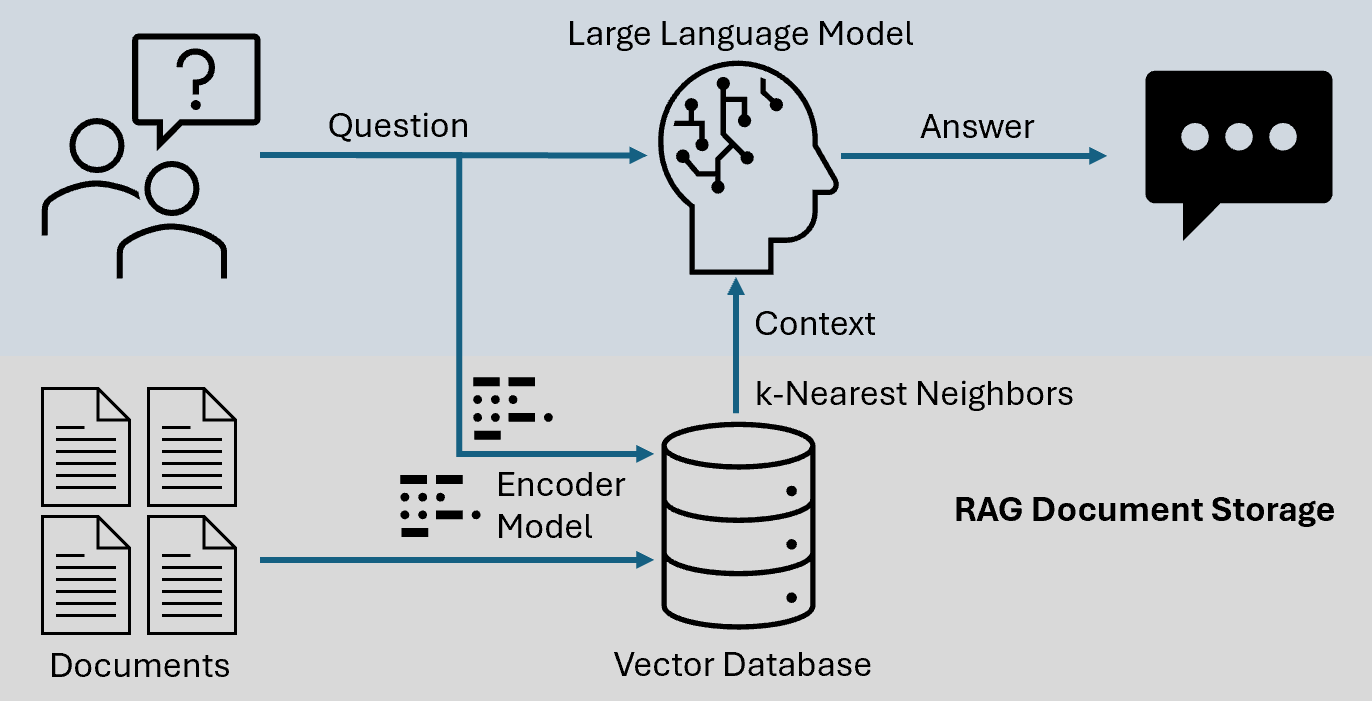

---
## 📦 CÉLULA 1 — Instalação das bibliotecas

Vamos instalar tudo o que precisamos.  
No Colab isso leva cerca de 1-2 minutos.

In [ ]:
# Instala as bibliotecas necessárias
# PyMuPDF  → lê arquivos PDF
# sentence-transformers → cria embeddings (vetores) do texto
# faiss-cpu → banco de dados vetorial para busca rápida
# groq → client oficial da API Groq (LLM gratuito)

!pip install pymupdf sentence-transformers faiss-cpu groq -q

print("✅ Bibliotecas instaladas com sucesso!")

---
## 📥 CÉLULA 2 — Importações

Importamos os módulos que vamos usar ao longo do notebook.

In [ ]:
import fitz          # PyMuPDF — leitura de PDF
import numpy as np   # operações com vetores
import faiss         # busca por similaridade vetorial
import os
import textwrap

from sentence_transformers import SentenceTransformer
from groq import Groq

print("✅ Importações concluídas!")

---
## 🔑 CÉLULA 3 — Configurar a chave da API Groq

### Como obter sua chave GRATUITA:
1. Acesse: https://console.groq.com
2. Crie uma conta (pode usar o Google)
3. Vá em **API Keys** → **Create API Key**
4. Copie a chave e cole abaixo

> ⚠️ Nunca compartilhe sua chave publicamente!

In [ ]:
# Cole sua chave aqui
GROQ_API_KEY = "sua chave aqui!!!!"

# Cria o cliente Groq
cliente_llm = Groq(api_key=GROQ_API_KEY)

# Modelo gratuito e rápido
MODELO = "llama-3.3-70b-versatile"

# Teste rápido para ver se a chave funciona
try:
    teste = cliente_llm.chat.completions.create(
        model=MODELO,
        messages=[{"role": "user", "content": "Responda apenas: OK"}],
        max_tokens=5
    )
    print("✅ Conexão com Groq funcionando! Resposta:", teste.choices[0].message.content)
except Exception as e:
    print("❌ Erro na conexão:", e)
    print("Verifique se sua chave está correta.")

---
## 📄 CÉLULA 4 — Upload dos documentos PDF

Faça o upload dos arquivos PDF das condições gerais de seguro.  

**Execute a célula abaixo** e selecione os arquivos PDF quando aparecer o botão.

In [ ]:
from google.colab import files

print("📂 Selecione os arquivos PDF das condições gerais de seguro:")
uploaded = files.upload()

# Lista os arquivos carregados
arquivos_pdf = list(uploaded.keys())
print(f"\n✅ {len(arquivos_pdf)} arquivo(s) carregado(s):")
for arq in arquivos_pdf:
    print(f"   📄 {arq}")

---
## 📖 CÉLULA 5 — Ler e dividir os PDFs em pedaços (chunks)

### Por que dividir em chunks?

Os modelos de linguagem têm um limite de texto que conseguem processar de uma vez.  
Além disso, queremos buscar apenas os **trechos mais relevantes** para cada pergunta,  
não mandar o documento inteiro para o LLM.

```
Documento completo (70+ páginas)
         ↓  dividir
[chunk_1] [chunk_2] [chunk_3] ... [chunk_N]
         ↓  buscar
Apenas os 3-5 chunks mais relevantes para a pergunta
```

**Tamanho do chunk:** 500 caracteres com sobreposição de 100  
(a sobreposição evita perder informação na "costura" entre chunks)

In [ ]:
def ler_pdf(caminho):
    """Lê um PDF e retorna o texto completo."""
    doc = fitz.open(caminho)
    texto = ""
    for pagina in doc:
        texto += pagina.get_text()
    return texto


def dividir_em_chunks(texto, tamanho=500, sobreposicao=100):
    """Divide o texto em pedaços menores com sobreposição."""
    chunks = []
    inicio = 0
    while inicio < len(texto):
        fim = inicio + tamanho
        chunk = texto[inicio:fim].strip()
        if chunk:  # ignora chunks vazios
            chunks.append(chunk)
        inicio += tamanho - sobreposicao  # avança com sobreposição
    return chunks


# Lê todos os PDFs e cria os chunks
todos_chunks = []
metadados = []  # guarda de qual arquivo veio cada chunk

for nome_arquivo in arquivos_pdf:
    print(f"📖 Lendo: {nome_arquivo}")
    texto = ler_pdf(nome_arquivo)
    chunks = dividir_em_chunks(texto)
    todos_chunks.extend(chunks)
    metadados.extend([nome_arquivo] * len(chunks))
    print(f"   → {len(chunks)} chunks criados")

print(f"\n✅ Total de chunks: {len(todos_chunks)}")
print(f"\n--- Exemplo de chunk ---")
print(todos_chunks[0])  # mostra um chunk de exemplo

---
## 🧠 CÉLULA 6 — Criar Embeddings (vetores)

### O que são embeddings?

**Embedding** é uma forma de representar texto como um vetor de números.  
Textos com significado similar ficam **próximos** no espaço vetorial.

```
"carência de 90 dias"     → [0.12, -0.45, 0.78, ...] (384 números)
"período de espera"       → [0.11, -0.43, 0.81, ...] (384 números) ← SIMILAR!
"cobertura funeral"       → [0.67,  0.23, -0.12, ...] (384 números) ← DIFERENTE
```

Usamos o modelo `paraphrase-multilingual-MiniLM-L12-v2` que:
- É **gratuito e local** (roda no Colab sem API)
- Funciona muito bem em **português**
- É leve e rápido

> ⏳ Esta célula pode demorar 1-3 minutos para baixar e processar.

In [ ]:
print("⏳ Carregando modelo de embeddings (aguarde)...")

# Carrega o modelo de embeddings multilíngue (funciona em português!)
modelo_embedding = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

print("✅ Modelo carregado!")
print("⏳ Criando embeddings dos chunks (aguarde)...")

# Cria o vetor de embedding para cada chunk
embeddings = modelo_embedding.encode(
    todos_chunks,
    show_progress_bar=True,
    convert_to_numpy=True
)

print(f"\n✅ Embeddings criados!")
print(f"   Formato: {embeddings.shape}")
print(f"   → {embeddings.shape[0]} chunks × {embeddings.shape[1]} dimensões por vetor")

---
## 🗄️ CÉLULA 7 — Criar o índice FAISS (banco de dados vetorial)

### O que é FAISS?

**FAISS** (Facebook AI Similarity Search) é uma biblioteca para busca rápida por similaridade entre vetores.

Imagine uma **biblioteca organizada por significado**:  
ao invés de buscar por palavras exatas, você busca pelo **sentido** da sua pergunta.

```
Pergunta: "Qual o prazo de carência?"
    ↓ vira vetor
[0.15, -0.42, 0.79, ...]
    ↓ FAISS busca os mais próximos
chunk_47: "carência de 90 dias..."         → distância: 0.12 ✅
chunk_23: "período de espera de 3 meses..." → distância: 0.18 ✅
chunk_89: "cobertura por morte acidental..." → distância: 0.91 ❌
```

In [ ]:
# Dimensão dos vetores (depende do modelo de embedding)
dimensao = embeddings.shape[1]

# Cria o índice FAISS usando similaridade por produto interno (L2 = distância euclidiana)
indice = faiss.IndexFlatL2(dimensao)

# Adiciona todos os embeddings ao índice
indice.add(embeddings)

print(f"✅ Índice FAISS criado!")
print(f"   Total de vetores indexados: {indice.ntotal}")
print(f"   Dimensão de cada vetor: {dimensao}")
print("\n🎉 Base de conhecimento pronta para consultas!")

---
## 🔎 CÉLULA 8 — Função de busca (Retrieval)

Esta função recebe uma pergunta e retorna os chunks mais relevantes.

Ela faz o **R** do RAG: **Retrieval** (recuperação).

In [ ]:
def buscar_chunks_relevantes(pergunta, top_k=4):
    """
    Recebe uma pergunta e retorna os top_k chunks mais relevantes.

    Parâmetros:
        pergunta (str): a pergunta do usuário
        top_k (int): quantos chunks retornar (padrão: 4)

    Retorna:
        lista de tuplas: (chunk_texto, nome_arquivo, score)
    """
    # 1. Transforma a pergunta em vetor
    vetor_pergunta = modelo_embedding.encode([pergunta], convert_to_numpy=True)

    # 2. Busca os top_k mais próximos no FAISS
    distancias, indices = indice.search(vetor_pergunta, top_k)

    # 3. Monta o resultado
    resultados = []
    for i, idx in enumerate(indices[0]):
        resultados.append((
            todos_chunks[idx],          # texto do chunk
            metadados[idx],             # arquivo de origem
            float(distancias[0][i])     # distância (menor = mais similar)
        ))
    return resultados


# === TESTE DA BUSCA ===
pergunta_teste = "Qual o CNPJ da Seguradora Protege Mais Seguros"
print(f"🔍 Testando busca para: '{pergunta_teste}'\n")
print("-" * 60)

resultados = buscar_chunks_relevantes(pergunta_teste, top_k=4)
for i, (chunk, arquivo, score) in enumerate(resultados):
    print(f"\n📌 Resultado {i+1} | Score: {score:.2f} | Arquivo: {arquivo[:40]}...")
    print(textwrap.fill(chunk[:300], width=70))
    print("...")

---
## 🤖 CÉLULA 9 — Função de geração (o "G" do RAG)

Agora combinamos a busca com o LLM para gerar uma resposta.

### Como funciona o prompt?

```
SYSTEM: "Você é especialista em seguros. Use APENAS os trechos abaixo."

USER: "Contexto:\n[chunk1]\n[chunk2]\n...\n\nPergunta: [pergunta do usuário]"

ASSISTANT: [resposta baseada nos documentos] ✅
```

Ao forçar o modelo a usar apenas o contexto fornecido, reduzimos as alucinações.

In [ ]:
def responder_com_rag(pergunta, top_k=4, verbose=False):
    """
    Pipeline RAG completo:
      1. Busca chunks relevantes
      2. Monta o contexto
      3. Envia para o LLM (Groq)
      4. Retorna a resposta

    Se verbose=True, mostra os chunks encontrados antes da resposta.
    """

    # ── PASSO 1: Retrieval ──────────────────────────────
    chunks_relevantes = buscar_chunks_relevantes(pergunta, top_k=top_k)

    # ── PASSO 2: Montar contexto ────────────────────────
    contexto = ""
    for i, (chunk, arquivo, _) in enumerate(chunks_relevantes):
        nome_curto = arquivo.replace(".pdf", "")[:50]
        contexto += f"[Trecho {i+1} — {nome_curto}]:\n{chunk}\n\n"

    if verbose:
        print("📋 CONTEXTO ENVIADO AO LLM:")
        print("-" * 60)
        print(contexto[:800], "...")
        print("-" * 60)

    # ── PASSO 3: Geração com o LLM ──────────────────────
    system_prompt = """Você é um especialista em seguros no Brasil.
Responda APENAS com base nos trechos fornecidos abaixo.
Se a informação não estiver nos trechos, diga claramente que não encontrou.
Seja claro, objetivo e cite de qual documento vem a informação.
Responda em português."""

    user_message = f"""Use os trechos abaixo para responder:

{contexto}

Pergunta: {pergunta}"""

    resposta = cliente_llm.chat.completions.create(
        model=MODELO,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user",   "content": user_message}
        ],
        temperature=0.2,   # baixo = mais fiel ao documento, menos criativo
        max_tokens=600
    )

    return resposta.choices[0].message.content


print("✅ Função RAG criada com sucesso!")

---
## 🧪 CÉLULA 10 — Teste com perguntas reais!

Vamos testar o sistema com perguntas sobre os documentos de seguro.

> Experimente mudar a pergunta para outras como:
> - "Qual é o valor do capital segurado para casos de morte natural ou acidental descrito na apólice?"
> - "Quem são os beneficiários indicados na apólice e qual é a participação percentual de cada um?"
> - "Quais serviços estão incluídos na Assistência Residencial 24 Horas do Plano Conforto Lar?"
> - "O que pode acontecer caso o segurado deixe de pagar o prêmio mensal da apólice?"


In [ ]:
# ✏️ Mude a pergunta aqui!
minha_pergunta = "Quais os dados do segurado?"

print("="*65)
print(f"❓ PERGUNTA: {minha_pergunta}")
print("="*65)

resposta = responder_com_rag(minha_pergunta, top_k=4, verbose=False)

print("\n🤖 RESPOSTA DO RAG:")
print("-"*65)
print(textwrap.fill(resposta, width=65))
print("-"*65)

---
## 🔬 CÉLULA 11 — Modo DEBUG: veja o que acontece por baixo

Agora vamos rodar com `verbose=True` para ver o contexto que o LLM recebe.  
Isso ajuda a entender **por que** o modelo deu aquela resposta.

In [ ]:
# A mesma pergunta, mas mostrando o que vai para o LLM
minha_pergunta = "O que é cobertura de invalidez por acidente?"

print("="*65)
print(f"❓ PERGUNTA: {minha_pergunta}")
print("="*65)

resposta = responder_com_rag(minha_pergunta, top_k=4, verbose=True)

print("\n🤖 RESPOSTA FINAL:")
print("-"*65)
print(textwrap.fill(resposta, width=65))
print("-"*65)

In [ ]:
# A mesma pergunta, mas mostrando o que vai para o LLM
minha_pergunta = "Qual o valor do Capital segurado?"

print("="*65)
print(f"❓ PERGUNTA: {minha_pergunta}")
print("="*65)

resposta = responder_com_rag(minha_pergunta, top_k=4, verbose=True)

print("\n🤖 RESPOSTA FINAL:")
print("-"*65)
print(textwrap.fill(resposta, width=65))
print("-"*65)

In [ ]:
# A mesma pergunta, mas mostrando o que vai para o LLM
minha_pergunta = "Explique o serviço de eletricista coberto pela apólice."

print("="*65)
print(f"❓ PERGUNTA: {minha_pergunta}")
print("="*65)

resposta = responder_com_rag(minha_pergunta, top_k=4, verbose=True)

print("\n🤖 RESPOSTA FINAL:")
print("-"*65)
print(textwrap.fill(resposta, width=65))
print("-"*65)

In [ ]:
# A mesma pergunta, mas mostrando o que vai para o LLM
minha_pergunta = "Quem são os beneficiários?"

print("="*65)
print(f"❓ PERGUNTA: {minha_pergunta}")
print("="*65)

resposta = responder_com_rag(minha_pergunta, top_k=4, verbose=True)

print("\n🤖 RESPOSTA FINAL:")
print("-"*65)
print(textwrap.fill(resposta, width=65))
print("-"*65)

---
## 💬 CÉLULA 12 — Mini chatbot interativo!

Vamos fazer um loop de perguntas e respostas.  
Digite `sair` para encerrar a sessão.

In [ ]:
# Verifica se as variáveis ainda estão na memória
def verificar_memoria():
    variaveis_necessarias = ["todos_chunks", "indice", "modelo_embedding", "cliente_llm"]
    faltando = [v for v in variaveis_necessarias if v not in globals()]
    if faltando:
        print(f"⚠️  Variáveis perdidas: {faltando}")
        print("👉 Rode todas as células anteriores: Menu → Runtime → Run all")
        return False
    return True


def chatbot():
    if not verificar_memoria():
        return

    print("=" * 55)
    print("🤖 CHATBOT RAG — Condições de Seguros")
    print("   Digite sua pergunta e pressione Enter")
    print("   Digite 'sair' para encerrar")
    print("=" * 55)

    historico = []

    while True:
        try:
            pergunta = input("\n❓ Você: ").strip()
        except (EOFError, KeyboardInterrupt):
            print("\n\n👋 Chatbot encerrado.")
            break

        if not pergunta:
            print("   (Digite algo ou 'sair')")
            continue

        if pergunta.lower() in ["sair", "exit", "quit", "q"]:
            print("\n👋 Encerrando. Até logo!")
            break

        # Verifica memória a cada pergunta
        if not verificar_memoria():
            break

        print("\n⏳ Buscando nos documentos...")

        try:
            resposta = responder_com_rag(pergunta, top_k=4)
            historico.append((pergunta, resposta))

            print("\n🤖 Assistente:")
            print("-" * 55)
            # Imprime linha a linha sem cortar palavras no meio
            for linha in resposta.split("\n"):
                if linha.strip():
                    print(textwrap.fill(linha, width=55))
                else:
                    print()
            print("-" * 55)
            print(f"   (Pergunta {len(historico)} desta sessão)")

        except Exception as e:
            print(f"\n❌ Erro ao gerar resposta: {e}")
            print("   Tente reformular a pergunta.")


# Inicia o chatbot
chatbot()

---
## 🧩 CÉLULA 13 — Exercícios para os alunos

### 🎯 Desafios para explorar e aprender mais:

**Nível 1 — Básico:**
1. Mude o tamanho do chunk (de 500 para 300 ou 800). O que muda nas respostas?
2. Mude o `top_k` de 4 para 2 ou 8. Como isso afeta a qualidade?
3. Mude a `temperature` de 0.2 para 0.9. O que acontece?

**Nível 2 — Intermediário:**
4. Adicione mais PDFs de outras seguradoras. O sistema consegue comparar?
5. Faça uma pergunta em inglês. O modelo multilíngue funciona?
6. Imprima os scores das buscas. Quais chunks ficam mais próximos?

**Nível 3 — Avançado:**
7. Salve os embeddings em disco para não precisar recalcular toda vez
8. Implemente um histórico de conversa (mande as últimas N perguntas também)
9. Tente outros modelos Groq: `llama3-70b-8192` ou `gemma2-9b-it`

---

## 📊 Resumo do fluxo RAG implementado

```
┌─────────────────────────────────────────────────────────────┐
│                    PIPELINE RAG COMPLETO                    │
├─────────────────────────────────────────────────────────────┤
│                                                             │
│  📄 PDFs  ──→  chunks  ──→  embeddings  ──→  FAISS Index   │
│                                               (offline)    │
│                                                             │
│  ❓ Pergunta  ──→  embedding  ──→  busca FAISS              │
│                                       ↓                    │
│                              top-k chunks relevantes       │
│                                       ↓                    │
│                          contexto + pergunta → Groq LLM    │
│                                       ↓                    │
│                              ✅ Resposta fundamentada       │
│                                                             │
└─────────────────────────────────────────────────────────────┘
```

### 🏆 O que você aprendeu:
- ✅ O conceito de RAG e por que ele existe
- ✅ Como transformar PDFs em chunks de texto
- ✅ O que são embeddings e como criá-los
- ✅ Como usar FAISS para busca por similaridade
- ✅ Como usar um LLM gratuito (Groq) via API
- ✅ Como montar um prompt de contexto eficiente
- ✅ Como construir um chatbot RAG do zero!